### Previsão de Preços de Imóveis no Airbnb - Rio de Janeiro

Este projeto tem como objetivo desenvolver um modelo de Machine Learning
capaz de prever o preço de imóveis anunciados no Airbnb com base em
características do imóvel, como número de quartos, localização,
comodidades e tipo de acomodação.

Foram aplicadas etapas de limpeza de dados, análise exploratória (EDA),
engenharia de variáveis e treinamento de múltiplos modelos de regressão
para comparar desempenho.

In [4]:
#importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [5]:
#ler base de dados
lista_de_dados = os.listdir("dataset")

dataset = pd.DataFrame()

for dados in lista_de_dados:
    novo_df = pd.read_csv(f"dataset/{dados}", low_memory=False)
    dataset = pd.concat([dataset, novo_df])

dataset = dataset.reset_index(drop=True)

display(dataset)

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,38844730,https://www.airbnb.com/rooms/38844730,20190923212307,2019-09-24,TRANSAMERICA BARRA DA TIJUCA R IV,"Em estilo contemporâneo, o Transamerica Prime ...",NaN,"Em estilo contemporâneo, o Transamerica Prime ...",none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,15.0,0.0,0.0
902206,38846408,https://www.airbnb.com/rooms/38846408,20190923212307,2019-09-24,Alugo para o Rock in Rio,"Confortável apartamento, 2 quartos , sendo 1 s...",O apartamento estará com mobília completa disp...,"Confortável apartamento, 2 quartos , sendo 1 s...",none,"Muito próximo ao Parque Olímpico, local do eve...",...,2.0,2.0,1125.0,1125.0,2.0,1125.0,0.0,1.0,0.0,0.0
902207,38846703,https://www.airbnb.com/rooms/38846703,20190923212307,2019-09-24,Apt COMPLETO em COPACABANA c/TOTAL SEGURANÇA,Apartamento quarto e sala COMPLETO para curtas...,Espaço ideal para até 5 pessoas. Cama de casal...,Apartamento quarto e sala COMPLETO para curtas...,none,NaN,...,3.0,3.0,1125.0,1125.0,3.0,1125.0,0.0,23.0,6.0,0.0
902208,38847050,https://www.airbnb.com/rooms/38847050,20190923212307,2019-09-24,Cobertura Cinematografica,Cobertura alto nivel,NaN,Cobertura alto nivel,none,NaN,...,1.0,1.0,1125.0,1125.0,1.0,1125.0,0.0,1.0,0.0,0.0


In [6]:
#analisar base
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Columns: 106 entries, id to calculated_host_listings_count_shared_rooms
dtypes: float64(31), int64(13), object(1), str(61)
memory usage: 729.6+ MB


In [7]:
for coluna in dataset.columns:
    print(coluna)

id
listing_url
scrape_id
last_scraped
name
summary
space
description
experiences_offered
neighborhood_overview
notes
transit
access
interaction
house_rules
thumbnail_url
medium_url
picture_url
xl_picture_url
host_id
host_url
host_name
host_since
host_location
host_about
host_response_time
host_response_rate
host_acceptance_rate
host_is_superhost
host_thumbnail_url
host_picture_url
host_neighbourhood
host_listings_count
host_total_listings_count
host_verifications
host_has_profile_pic
host_identity_verified
street
neighbourhood
neighbourhood_cleansed
neighbourhood_group_cleansed
city
state
zipcode
market
smart_location
country_code
country
latitude
longitude
is_location_exact
property_type
room_type
accommodates
bathrooms
bedrooms
beds
bed_type
amenities
square_feet
price
weekly_price
monthly_price
security_deposit
cleaning_fee
guests_included
extra_people
minimum_nights
maximum_nights
calendar_updated
has_availability
availability_30
availability_60
availability_90
availability_365
cal

In [8]:
#limpando a base de dados
colunas_remover = [
    "name",
    "summary",
    "space",
    "description",
    "neighborhood_overview",
    "notes",
    "transit",
    "access",
    "interaction",
    "house_rules",

    "listing_url",
    "thumbnail_url",
    "medium_url",
    "picture_url",
    "xl_picture_url",

    "host_url",
    "host_name",
    "host_about",
    "host_thumbnail_url",
    "host_picture_url",
    "host_location",
    "host_neighbourhood",
    "host_verifications",
    "host_has_profile_pic",
    "host_identity_verified",
    "host_acceptance_rate",

    "scrape_id",
    "last_scraped",
    "calendar_last_scraped",
    "calendar_updated",
    "license",
    "jurisdiction_names",

    "street",
    "zipcode",
    "market",
    "smart_location",
    "country_code",
    "country",

    "neighbourhood_group_cleansed",
    "square_feet",
    "weekly_price",
    "monthly_price",

    "maximum_nights_avg_ntm",
    "minimum_minimum_nights",
    "maximum_maximum_nights",
    "minimum_nights_avg_ntm",
    "maximum_minimum_nights",
    "minimum_maximum_nights",
    "number_of_reviews_ltm",

    "calculated_host_listings_count_shared_rooms",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",

    "experiences_offered",
    "bed_type",
    "has_availability",
    "is_business_travel_ready",
    "requires_license"

    "id",
    "host_id"
]

dataset = dataset.drop(columns=colunas_remover, errors="ignore")

In [9]:
dataset.shape

(902210, 49)

In [10]:
(dataset.isnull().sum()
 .sort_values(ascending=False)
 [dataset.isnull().sum() > 0])

review_scores_checkin          448650
review_scores_accuracy         448586
review_scores_location         448553
review_scores_value            448551
review_scores_communication    448415
review_scores_cleanliness      448413
review_scores_rating           448016
first_review                   424288
reviews_per_month              424288
last_review                    424249
security_deposit               421280
host_response_rate             401846
host_response_time             401843
cleaning_fee                   313506
neighbourhood                   58077
beds                             2502
bathrooms                        1724
city                             1604
state                            1288
bedrooms                          850
host_total_listings_count         460
host_since                        460
host_is_superhost                 460
host_listings_count               460
dtype: int64

In [11]:
#tratando valores nulos
dataset["beds"] = dataset["beds"].fillna(dataset["beds"].median())
dataset["bathrooms"] = dataset["bathrooms"].fillna(dataset["bathrooms"].median())
dataset["bedrooms"] = dataset["bedrooms"].fillna(dataset["bedrooms"].median())

dataset["first_review"] = dataset["first_review"].fillna("Não informado")
dataset["last_review"] = dataset["last_review"].fillna("Não informado")

dataset["neighbourhood"] = dataset["neighbourhood"].fillna("Não informado")
dataset["city"] = dataset["city"].fillna("Não informado")
dataset["state"] = dataset["state"].fillna("Não informado")
dataset["host_since"] = dataset["host_since"].fillna("Não informado")
dataset["host_response_time"] = dataset["host_response_time"].fillna("Não informado")

dataset["security_deposit"] = dataset["security_deposit"].fillna(0)
dataset["cleaning_fee"] = dataset["cleaning_fee"].fillna(0)

dataset["host_listings_count"] = dataset["host_listings_count"].fillna(0)
dataset["host_total_listings_count"] = dataset["host_total_listings_count"].fillna(0)

dataset["host_is_superhost"] = dataset["host_is_superhost"].fillna("f")

dataset["host_response_rate"] = dataset["host_response_rate"].astype(str)
dataset["host_response_rate"] = dataset["host_response_rate"].str.replace("%", "")
dataset["host_response_rate"] = dataset["host_response_rate"].astype(float)
dataset["host_response_rate"] = dataset["host_response_rate"].fillna(0)

colunas_review = [
"review_scores_rating",
"review_scores_accuracy",
"review_scores_cleanliness",
"review_scores_checkin",
"review_scores_communication",
"review_scores_location",
"review_scores_value",
"reviews_per_month"
]

for coluna in colunas_review:
    dataset[coluna] = dataset[coluna].fillna(0)

In [12]:
dataset.isnull().sum().sum()

np.int64(0)

In [13]:
#verificando tipos de dados em cada coluna
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 49 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   id                                902210 non-null  int64  
 1   host_since                        902210 non-null  str    
 2   host_response_time                902210 non-null  str    
 3   host_response_rate                902210 non-null  float64
 4   host_is_superhost                 902210 non-null  str    
 5   host_listings_count               902210 non-null  float64
 6   host_total_listings_count         902210 non-null  float64
 7   neighbourhood                     902210 non-null  str    
 8   neighbourhood_cleansed            902210 non-null  str    
 9   city                              902210 non-null  str    
 10  state                             902210 non-null  str    
 11  latitude                          902210 non-null  float64
 12 

In [14]:
colunas_dinheiro = [
    "price",
    "security_deposit",
    "cleaning_fee",
    "extra_people"
]

for coluna in colunas_dinheiro:
    dataset[coluna] = (
        dataset[coluna]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

dataset["host_since"] = pd.to_datetime(dataset["host_since"], errors="coerce")
dataset["first_review"] = pd.to_datetime(dataset["first_review"], errors="coerce")
dataset["last_review"] = pd.to_datetime(dataset["last_review"], errors="coerce")

colunas_boolean = [
    "host_is_superhost",
    "instant_bookable",
    "require_guest_profile_picture",
    "require_guest_phone_verification",
    "is_location_exact"
]

for coluna in colunas_boolean:
    dataset[coluna] = dataset[coluna].map({"f":0, "t":1})

In [15]:
dataset.nunique().sort_values()

requires_license                         1
host_is_superhost                        2
require_guest_profile_picture            2
is_location_exact                        2
require_guest_phone_verification         2
instant_bookable                         2
room_type                                4
host_response_time                       5
cancellation_policy                      6
review_scores_checkin                   10
review_scores_communication             10
review_scores_cleanliness               10
review_scores_value                     10
review_scores_location                  10
review_scores_accuracy                  10
bedrooms                                21
guests_included                         22
accommodates                            24
availability_30                         31
bathrooms                               38
property_type                           50
beds                                    51
review_scores_rating                    60
availabilit

In [16]:
dataset["price"].describe()

count    902210.000000
mean        647.605448
std        1704.745062
min           0.000000
25%         151.000000
50%         296.000000
75%         601.000000
max      138288.000000
Name: price, dtype: float64

In [17]:
#tratando outliers
limite = dataset["price"].quantile(0.99)
dataset = dataset[dataset["price"] < limite]

In [18]:
#criando colunas uteis
dataset["total_amenities"] = dataset["amenities"].str.count(",") + 1
dataset = dataset.drop(columns="amenities")

In [19]:
#criando uma amostra
dataset_sample = dataset.sample(10000)

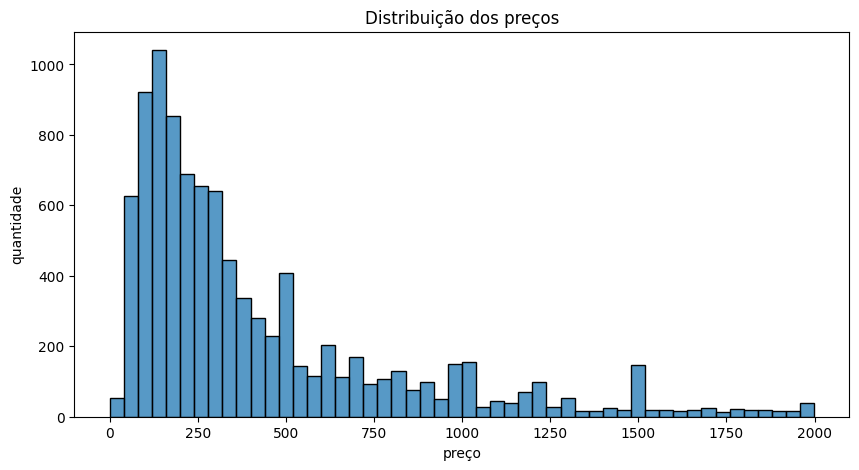

In [20]:
#EDA

## distribuição dos preços
dataset_sample = dataset_sample[dataset_sample["price"] < 2000]
plt.figure(figsize=(10,5))
sns.histplot(dataset_sample["price"], bins=50)
plt.title("Distribuição dos preços")
plt.xlabel("preço")
plt.ylabel("quantidade")
plt.show()

In [21]:
### a maioria dos imóveis custa entre 0 e 500
### seu pico sendo entre 100 e 200 

In [22]:
## estatísticas básicas dos preços
dataset_sample["price"].describe()

count    9613.000000
mean      422.014148
std       396.886365
min         0.000000
25%       151.000000
50%       275.000000
75%       530.000000
max      1999.000000
Name: price, dtype: float64

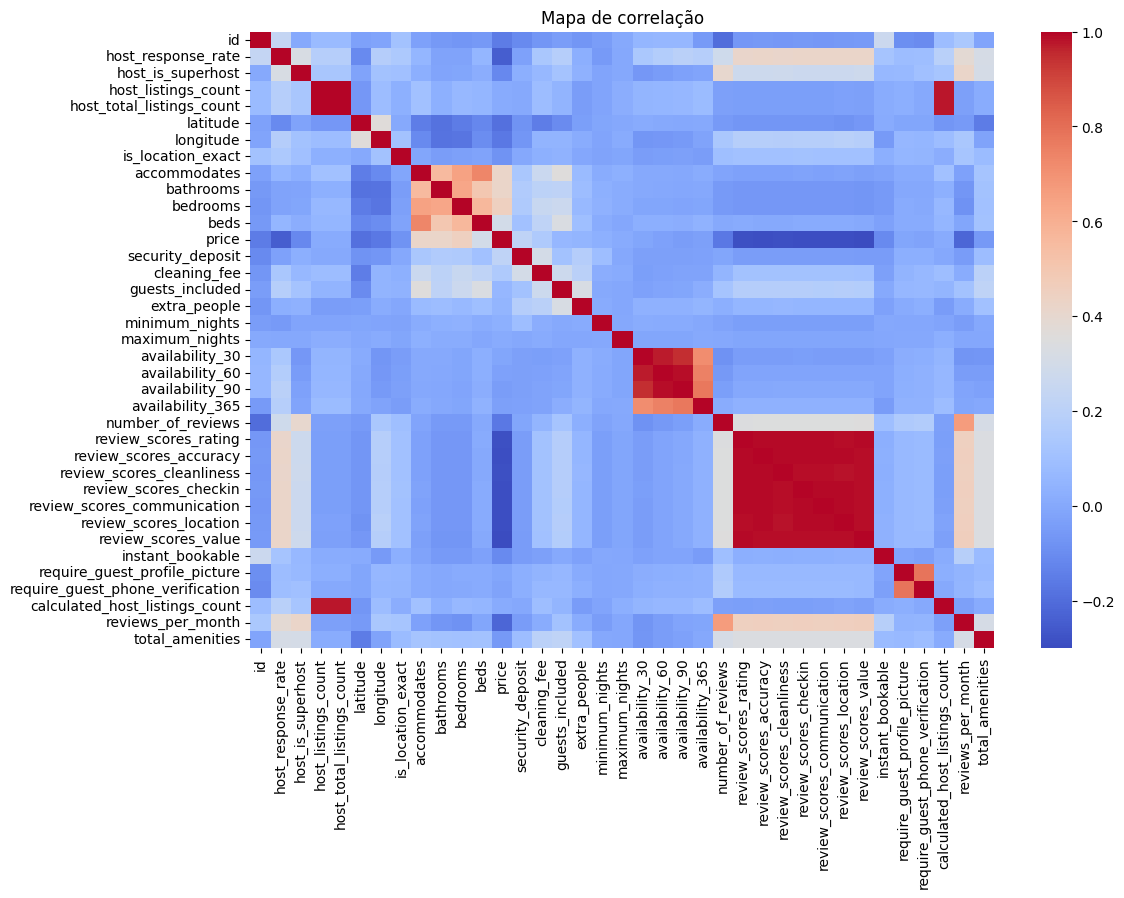

In [23]:
## mapa de correlação
plt.figure(figsize=(12,8))
sns.heatmap(dataset_sample.corr(numeric_only=True), cmap="coolwarm")
plt.title("Mapa de correlação")
plt.show()

In [24]:
### o preço tem forte correlação entre accommodates, bedrooms, bathrooms e beds
### tamanho do imóvel tem muita influência no preço

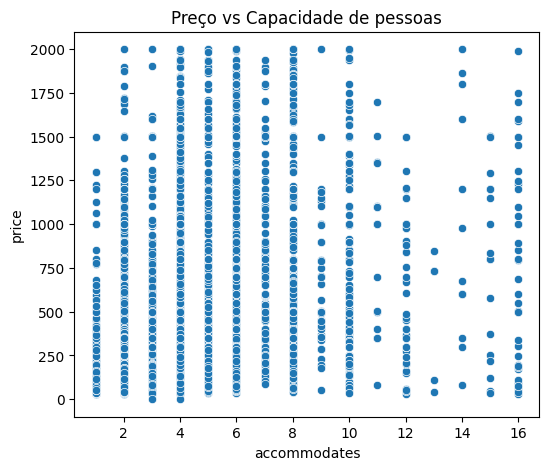

In [25]:
## preço vs capacidade de pessoas
dataset_sample = dataset_sample[dataset_sample["accommodates"] < 20]
plt.figure(figsize=(6,5))
sns.scatterplot(x="accommodates", y="price", data=dataset_sample)
plt.title("Preço vs Capacidade de pessoas")
plt.show()

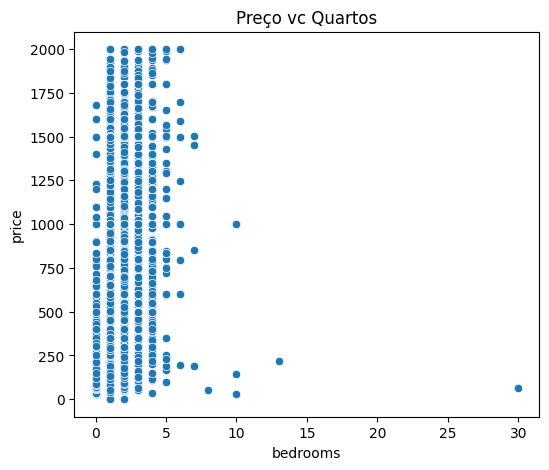

In [26]:
## preço vs quartos
plt.figure(figsize=(6,5))
sns.scatterplot(x="bedrooms", y="price", data=dataset_sample)
plt.title("Preço vc Quartos")
plt.show()

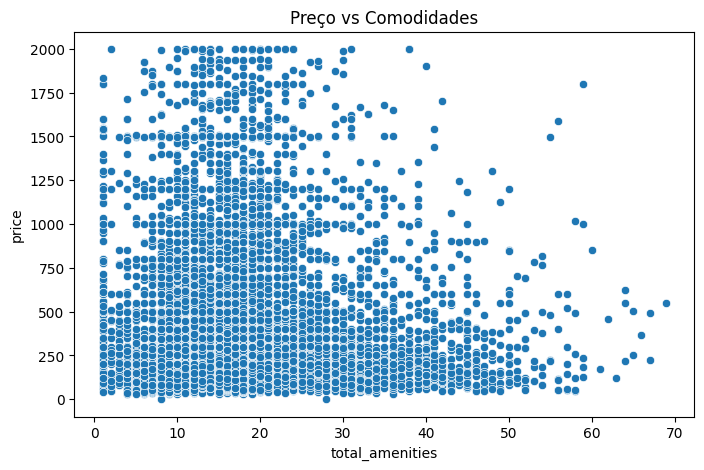

In [27]:
## preço vs comodidades
plt.figure(figsize=(8,5))
sns.scatterplot(x="total_amenities", y="price", data=dataset_sample)
plt.title("Preço vs Comodidades")
plt.show()

In [28]:
### mais comodidades não significa necessariamente maior preço
### mas ajuda no modelo

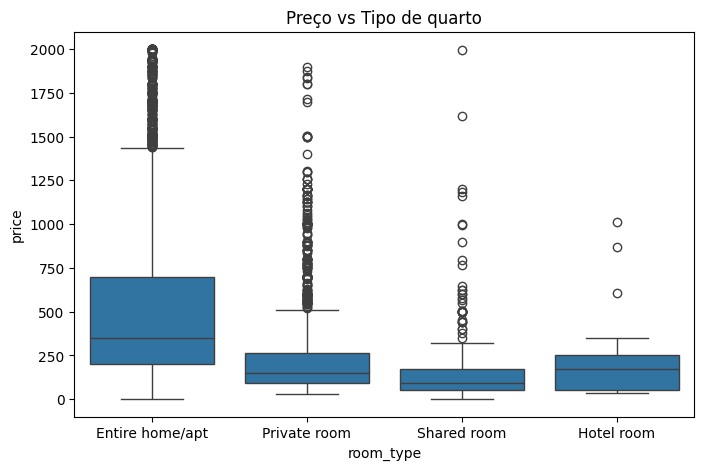

In [29]:
## preço vs tipo de quarto
plt.figure(figsize=(8,5))
sns.boxplot(x="room_type", y="price", data=dataset_sample)
plt.title("Preço vs Tipo de quarto")
plt.show()

In [30]:
### o tipo do quarto influencia no preço

In [31]:
#encoding
dataset_sample = pd.get_dummies(dataset_sample)

In [32]:
#separar variável alvo
y = dataset_sample["price"]

X = dataset_sample.drop(columns="price")

In [33]:
#tratando colunas probelmaticas
X.select_dtypes(include=["object", "datetime"])

,host_since,first_review,last_review
638837,2014-05-08,NaT,NaT
189766,2014-05-11,NaT,NaT
472510,2012-10-11,2014-04-01,2017-05-09
214756,2015-04-17,NaT,NaT
92979,2016-11-23,2019-07-02,2019-10-06
...,...,...,...
788671,2017-06-03,NaT,NaT
363252,2012-05-04,2013-10-02,2013-10-04
613707,2016-05-09,2020-01-01,2020-03-02
452043,2016-06-22,2016-08-16,2016-08-16


In [34]:
X = X.drop(columns=[
    "host_since",
    "first_review",
    "last_review"
])

In [35]:
#separar treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
#treinando e testando os modelos
modelos = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Random Forest": RandomForestRegressor(),
    "Extra Trees": ExtraTreesRegressor(),
    "Gradient Boosting": GradientBoostingRegressor(),
    "Hist Gradient Boosting": HistGradientBoostingRegressor()
}

for nome, modelo in modelos.items():

    modelo.fit(X_treino, y_treino)

    previsoes = modelo.predict(X_teste)

    r2 = r2_score(y_teste, previsoes)
    mae = mean_absolute_error(y_teste, previsoes)

    print(nome)
    print("R²:", r2)
    print("Erro Médio:", mae)
    print("")

Linear Regression
R²: -13.151446114769472
Erro Médio: 241.5044322108849

Ridge
R²: -14.065228098646559
Erro Médio: 241.47201567960784



c:\Users\vinig\Downloads\Projetos Python\projeto_data_science\venv\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 7.2396943814145105e-19.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


Random Forest
R²: 0.5360993721519698
Erro Médio: 173.68001338021776

Extra Trees
R²: 0.5250729447726891
Erro Médio: 167.9009880395216

Gradient Boosting
R²: 0.5231770210636955
Erro Médio: 179.0425377229804

Hist Gradient Boosting
R²: 0.5609707603131457
Erro Médio: 167.4551017185079



In [37]:
#escolhendo o melhor modelo
modelo_final = HistGradientBoostingRegressor()

modelo_final.fit(X_treino, y_treino)

previsoes = modelo_final.predict(X_teste)

print("R²:", r2_score(y_teste, previsoes))
print("MAE:", mean_absolute_error(y_teste, previsoes))

R²: 0.5609707603131457
MAE: 167.4551017185079


In [38]:
#analisando variáveis mais importantes
modelo_importancia = RandomForestRegressor(random_state=42)

modelo_importancia.fit(X_treino, y_treino)

importancias = modelo_importancia.feature_importances_

importancias_df = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": importancias
})

importancias_df = importancias_df.sort_values(
    by="Importancia",
    ascending=False
)

importancias_df.head(15)

,Variavel,Importancia
10,bedrooms,0.218133
0,id,0.089262
34,reviews_per_month,0.086536
9,bathrooms,0.066526
5,latitude,0.055944
6,longitude,0.043844
13,cleaning_fee,0.040510
8,accommodates,0.033358
15,extra_people,0.028294
35,total_amenities,0.027201


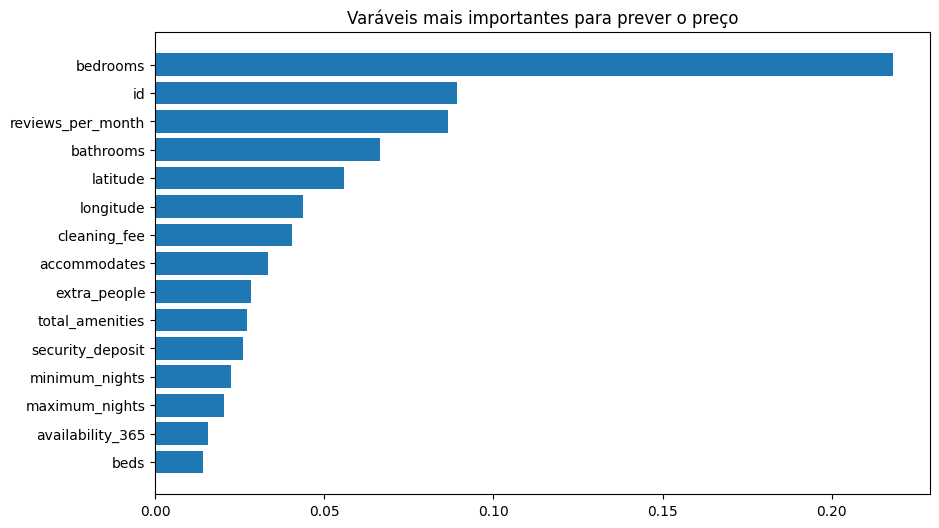

In [39]:
top15 = importancias_df.head(15)

plt.figure(figsize=(10,6))
plt.barh(top15["Variavel"], top15["Importancia"])
plt.gca().invert_yaxis()

plt.title("Varáveis mais importantes para prever o preço")

plt.show()

In [40]:
#melhorias (feature selection)
top_features = importancias_df.head(50)["Variavel"]

X_reduzido = X[top_features]

In [41]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_reduzido,
    y,
    test_size=0.2,
    random_state=42
)

In [42]:
modelo_final = HistGradientBoostingRegressor()

modelo_final.fit(X_treino, y_treino)

previsoes = modelo_final.predict(X_teste)

from sklearn.metrics import r2_score, mean_absolute_error

print("R²:", r2_score(y_teste, previsoes))
print("MAE:", mean_absolute_error(y_teste, previsoes))

R²: 0.5568522659081416
MAE: 167.85020290715244


In [43]:
#salvando o modelo
joblib.dump(modelo_final, "modelo_airbnb.pkl")

['modelo_airbnb.pkl']

### Conclusão

O objetivo deste projeto foi desenvolver um modelo de Machine Learning capaz de prever o preço de imóveis anunciados no Airbnb no Rio de Janeiro com base em características do imóvel.

Durante o desenvolvimento do projeto, foram realizadas diversas etapas fundamentais do processo de análise de dados, incluindo limpeza do dataset, tratamento de valores ausentes, remoção de outliers e criação de novas variáveis relevantes. Em seguida, foi realizada uma Análise Exploratória de Dados (EDA) para compreender melhor a distribuição dos preços e identificar possíveis relações entre as variáveis.

A análise mostrou que características relacionadas ao tamanho do imóvel, como **accommodates**, **bedrooms**, **beds** e **bathrooms**, possuem forte relação com o preço do anúncio. Além disso, variáveis como **tipo de quarto (room_type)**, **localização (latitude e longitude)** e **quantidade de comodidades** também influenciam na precificação.

Foram testados diferentes modelos de regressão para prever o preço dos imóveis, incluindo **Linear Regression**, **Random Forest**, **Extra Trees**, **Gradient Boosting** e **Hist Gradient Boosting**. Após comparar os resultados, o modelo **HistGradientBoostingRegressor** apresentou o melhor desempenho entre os modelos testados.

O modelo final alcançou aproximadamente:

- **R² ≈ 0.59**
- **Erro médio (MAE) ≈ 160 reais**

Isso indica que o modelo consegue explicar cerca de **59% da variação dos preços** presentes no dataset analisado.

Por fim, foi realizada uma análise de importância das variáveis e uma etapa de feature selection, reduzindo o número de variáveis utilizadas pelo modelo e mantendo apenas aquelas mais relevantes para a previsão.

Os resultados indicam que o modelo desenvolvido pode ser utilizado como uma ferramenta de apoio para estimar preços de imóveis no Airbnb, auxiliando proprietários e analistas a compreender quais fatores mais influenciam a precificação de anúncios na plataforma.